In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Load config
import sys
import os
from pathlib import Path
import datajoint as dj
from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)

# Add the parent directory to the path so we can import modules properly
cwd = Path.cwd()
print(f"home directory: {cwd}")
relative_repo_path = "GitRepos/simulation_closed_loop"

# append repo path 
sys.path.append(str(cwd / relative_repo_path))

from model_in_the_loop.utils.hydra_utils import load_config,set_env_vars
cfg = load_config()
set_env_vars(cfg)  # set env variables for repo and data paths



/workspace/.venv/lib/python3.12/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


home directory: /gpfs01/euler/User/ssuhai


In [3]:
import thesis.code.analysis_closed_loop_experiments.rf_mei_test.utils.dj_utils as dj_ut
import thesis.code.analysis_closed_loop_experiments.rf_mei_test.rf_mei_test_tables as dj_tab

# import plotter
import thesis.code.plot.plot as plotter
plotter.set_default_params(kind='paper')

FIGURE_PATH = os.path.join(cfg.paths.repo_directory, 'thesis', 'figures', 'analysis_closed_loop_experiments', 'rf_mei_test')
os.makedirs(FIGURE_PATH, exist_ok=True)

In [4]:
print("importing dj_utils")
from thesis.code.analysis_closed_loop_experiments.rf_mei_test.utils.dj_utils import *

importing dj_utils


In [5]:
load_dj_config(
    config_file = os.path.join(cfg.paths.home_directory,cfg.paths.dj_config_directory, f'dj_{cfg.DJ.username}_conf.json'),
    schema_name =  f"ageuler_ssuhai_closed_loop_rf_mei"
)

[2025-11-26 13:48:56,555][INFO]: DataJoint is configured from /gpfs01/euler/User/ssuhai/datajoint/dj_ssuhai_conf.json


[2025-11-26 13:48:56,634][INFO]: DataJoint 0.14.6 connected to ssuhai@172.25.240.200:3306


schema_name: ageuler_ssuhai_closed_loop_rf_mei


In [6]:
prepclassifier_and_activate(
    output_folder = os.path.join(cfg.paths.home_directory,cfg.paths.rgc_output_directory),
)

In [8]:
UserInfo()

experimenter name of the experimenter,"data_dir path to header file, used for computed tables",field_loc string location for field,stimulus_loc string location for stimulus,animal_loc string location for number of animal (e.g. M1),datatype_loc string location for datatype (e.g. SMP),region_loc string location for region (e.g. LR or RR),cond1_loc string location for condition 1 (e.g. pharmacological),cond2_loc string location for condition 2 (e.g. pharmacological),cond3_loc string location for condition 3 (e.g. pharmacological),opticdisk_alias alias(es) for optic disk (separated by _),outline_alias alias(es) for retinal outline / edge (separated by _),highres_alias alias(es) for high resolution stack,mask_alias Ordered alias(es) for field roi mask (separated by _),pre_data_dir directory for h5 data files,raw_data_dir directory for smp and smh data files,"data_stack_name main data channel, e.g. OGB-1","alt_stack_name alternative data channel, e.g. SR101"
Deja,/gpfs01/euler/data/Data/Suhai/thesis/dj/FloDeja/,3,4,1,None,2,5,6,None,od_opticdisk_opticdisc,outline_edge,hq_hr_highresolution_512,chirp_mb_movingbar,Pre,Raw,wDataCh0,wDataCh1


In [9]:
userinfo = {
    'experimenter': 'Szatko',
    'data_dir': '/gpfs01/euler/data/Data/Szatko',
    'datatype_loc': 0,
    'animal_loc': 1,
    'region_loc': 2,
    'field_loc': 3,
    'stimulus_loc': 4,
    'cond1_loc': 5,    }
UserInfo().insert1(userinfo, skip_duplicates=True)

In [10]:
UserInfo()

experimenter name of the experimenter,"data_dir path to header file, used for computed tables",field_loc string location for field,stimulus_loc string location for stimulus,animal_loc string location for number of animal (e.g. M1),datatype_loc string location for datatype (e.g. SMP),region_loc string location for region (e.g. LR or RR),cond1_loc string location for condition 1 (e.g. pharmacological),cond2_loc string location for condition 2 (e.g. pharmacological),cond3_loc string location for condition 3 (e.g. pharmacological),opticdisk_alias alias(es) for optic disk (separated by _),outline_alias alias(es) for retinal outline / edge (separated by _),highres_alias alias(es) for high resolution stack,mask_alias Ordered alias(es) for field roi mask (separated by _),pre_data_dir directory for h5 data files,raw_data_dir directory for smp and smh data files,"data_stack_name main data channel, e.g. OGB-1","alt_stack_name alternative data channel, e.g. SR101"
Deja,/gpfs01/euler/data/Data/Suhai/thesis/dj/FloDeja/,3,4,1,None,2,5,6,None,od_opticdisk_opticdisc,outline_edge,hq_hr_highresolution_512,chirp_mb_movingbar,Pre,Raw,wDataCh0,wDataCh1
Szatko,/gpfs01/euler/data/Data/Szatko,3,4,1,0,2,5,None,None,od_opticdisk_opticdisc,outline_edge,hq_hr_highresolution_512,chirp_mb_movingbar,Pre,Raw,wDataCh0,wDataCh1


In [11]:
Stimulus()

stim_name Unique string identifier,"alias Strings (_ seperator) to identify this stimulus, not case sensitive!",stim_family To group stimuli (e.g. gChirp and lChirp) for downstream processing,framerate framerate in Hz,isrepeated Is the stimulus repeated? Used for snippets,ntrigger_rep Number of triggers (per repetition),stim_path Path to hdf5 file containing numerical array and info about stim,commit_id Commit id corresponding to stimulus entry in GitHub repo,stim_hash QDSpy hash,"trial_info trial information, e.g. directions of moving bar",stim_trace array of stimulus if available,"stim_dict stimulus information dictionary, contains e.g. spatial extent",snippet_base_dt Time used for snippet baseline estimation
circle,rf_rf1_rf2_rf3_rf4_rf5,,0.0,1,1,,,,=BLOB=,=BLOB=,=BLOB=,nan
densenoise,dn_noise_dn40m_noise40m,noise,5.0,0,1500,,,,=BLOB=,=BLOB=,=BLOB=,nan
gChirp,chirp_gchirp_globalchirp,chirp,0.0166667,1,2,,,,=BLOB=,=BLOB=,=BLOB=,nan
lChirp,lchirp_localchirp,chirp,0.0166667,1,2,,,,=BLOB=,=BLOB=,=BLOB=,nan
mouse_cam,mc00_mc01_mc02_mc03_mc04_mc05_mc06_mc07_mc08_mc09_mc10_mc11_mc12_mc13_mc14_mc15_mc16_mc17_mc18_mc19_mc00bd_mc01bd_mc02bd_mc03bd_mc04bd_mc05bd_mc06bd_mc07bd_mc08bd_mc09bd_mc10bd_mc11bd_mc12bd_mc13bd_mc14bd_mc15bd_mc16bd_mc17bd_mc18bd_mc19bd,natural,30.0,0,123,,,,=BLOB=,=BLOB=,=BLOB=,nan
movingbar,mb_mbar_bar_movingbar,movingbar,0.0166667,1,1,,,,=BLOB=,=BLOB=,=BLOB=,nan
nostim,nostim_none,,0.0,0,0,,,,=BLOB=,=BLOB=,=BLOB=,nan
optstim,mei_mei1_mei2_mei3_mei4_mei5,,0.0,1,1,,,,=BLOB=,=BLOB=,=BLOB=,nan


In [48]:
RawDataParams()

experimenter name of the experimenter,raw_id unique param set id,from_raw_data Load raw smp data (1) or h5 data (0),compute_from_stack Compute traces from stack. Otherwise try to import Igor traces.,include_artifacts automatically exclude all ROIs with artifacts?,trace_precision Compute traces with either line precision or pixel precision?,trigger_precision Compute triggers with either line precision or pixel precision?,"igor_roi_masks Either load or ignore existing ROI masks, e.g. from Igor"
Deja,1,1,1,0,line,line,no
Szatko,2,0,1,0,line,line,yes


In [47]:
# RawDataParams().insert1(dict(
#         experimenter="Szatko",
#         compute_from_stack=int(0),
#         raw_id=int(2),
#         include_artifacts=int(0),
#         from_raw_data=int(0),
#         igor_roi_masks='yes',
#         ))

RawDataParams().update1(dict(
experimenter="Szatko",
compute_from_stack=int(1),
raw_id=int(2),
include_artifacts=int(0),
from_raw_data=int(0),
igor_roi_masks='yes',
))

In [23]:
Experiment()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,header_path path to header file,header_name name of header file
Deja,2025-10-08,1,/gpfs01/euler/data/Data/Suhai/thesis/dj/FloDeja/20251008/1/,20251008_1#20176_left.ini
Deja,2025-10-08,2,/gpfs01/euler/data/Data/Suhai/thesis/dj/FloDeja/20251008/2/,20251008_1#20176_right.ini


experimenter name of the experimenter
Deja
Szatko


In [26]:
single_szatko_header_path = "/gpfs01/euler/data/Data/Szatko/20200226/1"
Experiment().rescan_filesystem(
    restrictions = {"experimenter": "Szatko"},
    restr_headers = [single_szatko_header_path]
)


Scanning for experimenter: Szatko
	header_path: /gpfs01/euler/data/Data/Szatko/20200226/1
		header_name: 20200226__left.ini
		Adding: {'experimenter': 'Szatko', 'date': datetime.datetime(2020, 2, 26, 0, 0), 'exp_num': 1}


In [28]:
Field().rescan_filesystem(verboselvl=1)
#RelativeFieldLocation().populate(processes=MULTIPROCESSING_THREADS, display_progress=True)
#Presentation().populate(processes=MULTIPROCESSING_THREADS, display_progress=True)

Found 32 files in 7 fields for key={'experimenter': 'Deja', 'date': datetime.date(2025, 10, 8), 'exp_num': 1, 'raw_id': 1}
Found 20 files in 3 fields for key={'experimenter': 'Deja', 'date': datetime.date(2025, 10, 8), 'exp_num': 2, 'raw_id': 1}
Found 32 files in 5 fields for key={'experimenter': 'Szatko', 'date': datetime.date(2020, 2, 26), 'exp_num': 1, 'raw_id': 2}
	Adding field: `{'field': 'GCL0', 'region': 'LR', 'cond1': 'control', 'experimenter': 'Szatko', 'date': datetime.date(2020, 2, 26), 'exp_num': 1, 'raw_id': 2}`
	Adding field: `{'field': 'GCL1', 'region': 'LR', 'cond1': 'control', 'experimenter': 'Szatko', 'date': datetime.date(2020, 2, 26), 'exp_num': 1, 'raw_id': 2}`
	Adding field: `{'field': 'GCL2', 'region': 'LR', 'cond1': 'control', 'experimenter': 'Szatko', 'date': datetime.date(2020, 2, 26), 'exp_num': 1, 'raw_id': 2}`
	Adding field: `{'field': 'GCL4', 'region': 'LR', 'cond1': 'control', 'experimenter': 'Szatko', 'date': datetime.date(2020, 2, 26), 'exp_num': 1, 'ra

In [29]:
Presentation().populate(processes=MULTIPROCESSING_THREADS, display_progress=True)

Presentation: 100%|██████████| 92/92 [00:20<00:00,  4.41it/s]


{'success_count': 92, 'error_list': []}

In [34]:
field_key = (Field() & "field='GCL0' AND experimenter='Szatko'").proj().fetch1()
print(field_key)

{'experimenter': 'Szatko', 'date': datetime.date(2020, 2, 26), 'exp_num': 1, 'raw_id': 2, 'field': 'GCL0', 'region': 'LR', 'cond1': 'control'}


In [35]:
RoiMask().rescan_filesystem(restrictions=field_key)

[]

In [41]:
Roi().populate()

{'success_count': 1, 'error_list': []}

In [45]:
Roi() & field_key

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),roi_id integer id of each ROI,roi_size number of pixels in ROI,roi_size_um2 size of ROI in micrometers squared,"roi_dia_um diameter of ROI in micrometers, if it was a circle",artifact_flag flag if roi contains light artifact (1) or not (0)
Szatko,2020-02-26,1,2,GCL0,LR,control,1,8,32.3687,6.41975,0
Szatko,2020-02-26,1,2,GCL0,LR,control,2,10,40.4609,7.1775,0
Szatko,2020-02-26,1,2,GCL0,LR,control,3,16,64.7375,9.07889,0
Szatko,2020-02-26,1,2,GCL0,LR,control,4,24,97.1062,11.1193,0
Szatko,2020-02-26,1,2,GCL0,LR,control,5,29,117.337,12.2228,0
Szatko,2020-02-26,1,2,GCL0,LR,control,6,23,93.0601,10.8852,0
Szatko,2020-02-26,1,2,GCL0,LR,control,7,22,89.014,10.6459,0
Szatko,2020-02-26,1,2,GCL0,LR,control,8,22,89.014,10.6459,0
Szatko,2020-02-26,1,2,GCL0,LR,control,9,75,303.457,19.6564,0
Szatko,2020-02-26,1,2,GCL0,LR,control,10,14,56.6453,8.49253,0


In [49]:
Traces().populate(processes=1)

{'success_count': 4, 'error_list': []}

In [51]:
PreprocessTraces().populate()

{'success_count': 524, 'error_list': []}

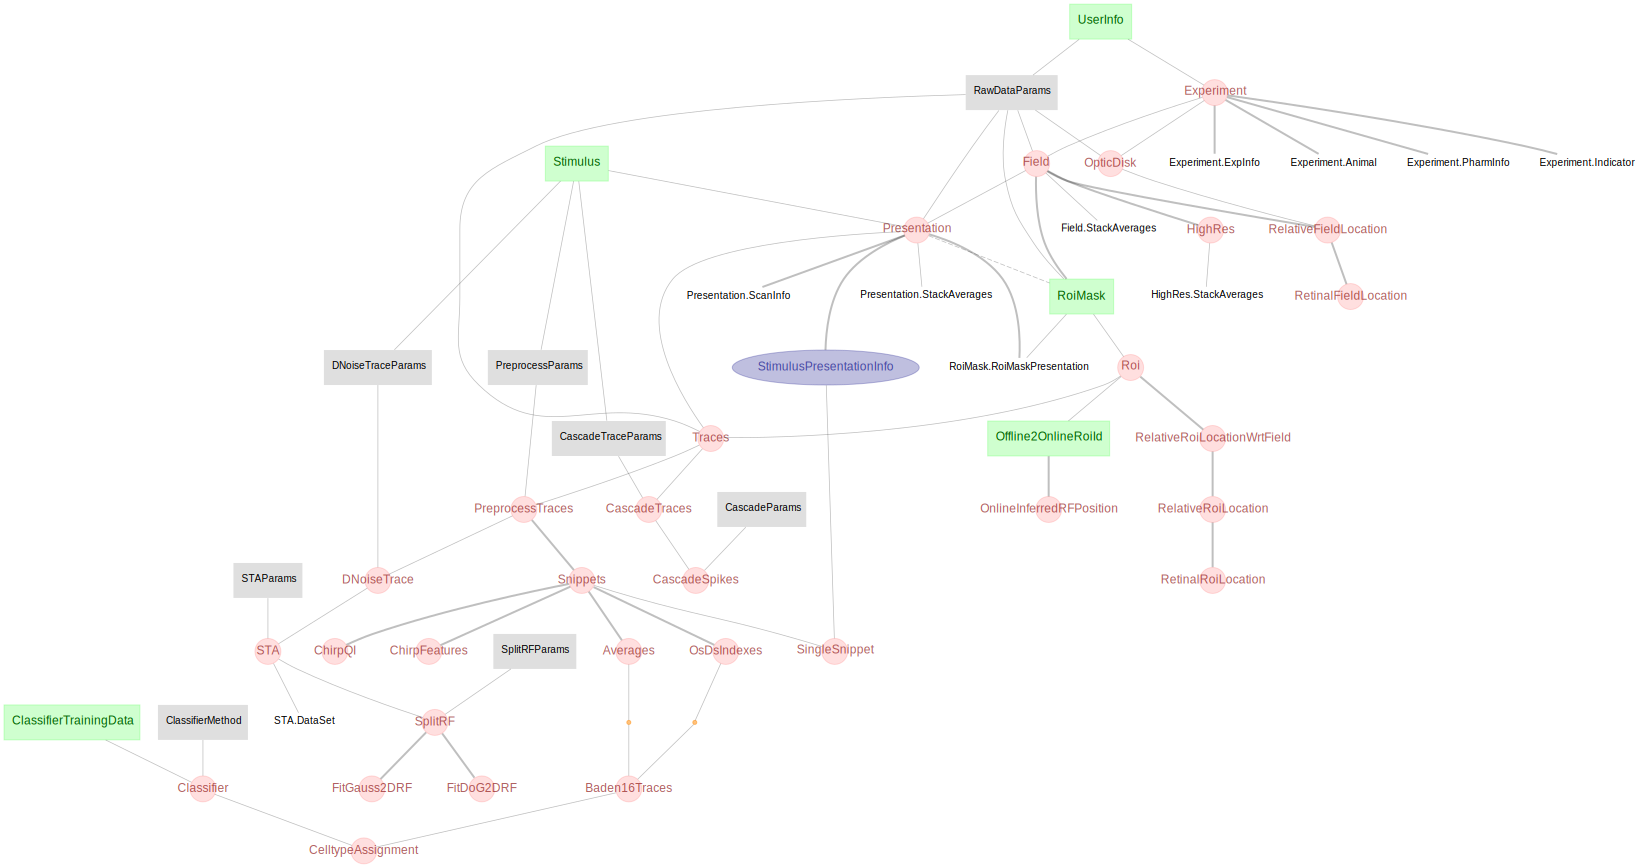

In [52]:
dj.ERD(schema)

In [57]:
sta_restriction = {"experimenter='Szatko' AND field='GCL0'"}

In [ ]:
DNoiseTrace().populate(sta_restriction)

{'success_count': 131, 'error_list': []}

In [58]:
STA().populate(sta_restriction)

{'success_count': 131, 'error_list': []}

In [59]:
SplitRF().populate(sta_restriction,processes = MULTIPROCESSING_THREADS)

{'success_count': 131, 'error_list': []}

In [60]:
SplitRF()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,dnoise_params_id unique param set id,sta_params_id unique param set id,split_rf_params_id unique param set id,srf spatio receptive field,trf temporal receptive field,"polarity Polarity of the RF, 1 for positive, -1 for negative",split_qidx Quality index as explained variance of the sRF tRF split between 0 and 1,trf_peak_idxs Indexes of peaks in tRF
Szatko,2020-02-26,1,2,GCL0,LR,control,densenoise,control,1,1,1,1,1,=BLOB=,=BLOB=,1,0.371912,=BLOB=
Szatko,2020-02-26,1,2,GCL0,LR,control,densenoise,control,2,1,1,1,1,=BLOB=,=BLOB=,1,0.429287,=BLOB=
Szatko,2020-02-26,1,2,GCL0,LR,control,densenoise,control,3,1,1,1,1,=BLOB=,=BLOB=,1,0.446584,=BLOB=
Szatko,2020-02-26,1,2,GCL0,LR,control,densenoise,control,4,1,1,1,1,=BLOB=,=BLOB=,1,0.429067,=BLOB=
Szatko,2020-02-26,1,2,GCL0,LR,control,densenoise,control,5,1,1,1,1,=BLOB=,=BLOB=,1,0.456149,=BLOB=
Szatko,2020-02-26,1,2,GCL0,LR,control,densenoise,control,6,1,1,1,1,=BLOB=,=BLOB=,1,0.716167,=BLOB=
Szatko,2020-02-26,1,2,GCL0,LR,control,densenoise,control,7,1,1,1,1,=BLOB=,=BLOB=,1,0.659743,=BLOB=
Szatko,2020-02-26,1,2,GCL0,LR,control,densenoise,control,8,1,1,1,1,=BLOB=,=BLOB=,1,0.57972,=BLOB=
Szatko,2020-02-26,1,2,GCL0,LR,control,densenoise,control,9,1,1,1,1,=BLOB=,=BLOB=,1,0.420437,=BLOB=
Szatko,2020-02-26,1,2,GCL0,LR,control,densenoise,control,10,1,1,1,1,=BLOB=,=BLOB=,1,0.411048,=BLOB=


In [113]:
FitGauss2DRF().populate(sta_restriction, processes = MULTIPROCESSING_THREADS)

{'success_count': 131, 'error_list': []}

In [126]:
rf_dn_data = (SplitRF() * FitGauss2DRF()).fetch("experimenter","date","exp_num","field","region","roi_id","srf","srf_params","rf_qidx",as_dict=True)
rf_dn_data = pd.DataFrame(rf_dn_data)
rf_dn_data.head()

,experimenter,date,exp_num,field,region,roi_id,srf,srf_params,rf_qidx
0,Szatko,2020-02-26,1,GCL0,LR,1,"[[0.034244426, 0.02747748, 0.0193875, 0.012470...","{'amplitude': 0.031816715001573015, 'x_mean': ...",0.196351
1,Szatko,2020-02-26,1,GCL0,LR,2,"[[0.0069292136, -0.0014174122, -0.007162196, 0...","{'amplitude': 0.04948285398009754, 'x_mean': 5...",0.456770
2,Szatko,2020-02-26,1,GCL0,LR,3,"[[-0.03888451, -0.02893071, -0.011553224, -0.0...","{'amplitude': 0.0438548900643526, 'x_mean': 6....",0.297409
3,Szatko,2020-02-26,1,GCL0,LR,4,"[[-0.00081503636, -0.0029323394, -0.0022267578...","{'amplitude': 0.03280112769309273, 'x_mean': 1...",0.179046
4,Szatko,2020-02-26,1,GCL0,LR,5,"[[0.016242944, 0.0024492962, -0.007861232, -0....","{'amplitude': -0.051243354372567135, 'x_mean':...",0.505551


# compare to model 

In [90]:
from openretina.models import *
SESSION_ID = "session_1_ventral1_20200226"

In [63]:
or_model = load_core_readout_from_remote("hoefling_2024_base_low_res", "cuda")


In [94]:
# make sure we have the correct sesion
db_roi_mask = (RoiMask() & field_key).fetch("roi_mask")[0]
np.all(or_model.data_info["sessions_kwargs"][SESSION_ID]["roi_mask"] == db_roi_mask)
or_rois = or_model.data_info["sessions_kwargs"][SESSION_ID]["roi_ids"]
session_readout = or_model.readout[SESSION_ID]

In [92]:
or_rois

array([  1,   2,   5,   7,   9,  11,  13,  14,  16,  17,  18,  19,  20,
        21,  22,  23,  24,  25,  27,  33,  35,  36,  37,  38,  39,  41,
        46,  47,  48,  49,  50,  52,  53,  54,  55,  58,  59,  60,  62,
        63,  64,  65,  66,  67,  68,  70,  73,  74,  76,  77,  78,  80,
        81,  82,  84,  90,  91,  94,  95,  96,  98, 101, 102, 103, 104,
       105, 106, 107, 111, 114, 115, 116, 117, 118, 119, 120, 122, 124,
       128, 130], dtype=int32)

In [96]:
roi_id2readout_idx = {roi_id: idx for idx, roi_id in enumerate(or_rois)}
readout_idx2roi_id = {idx: roi_id for idx, roi_id in enumerate(or_rois)}


In [127]:
data_path = "/gpfs01/euler/data/Data/Suhai/open-retina/model_rf"
rf_data = {SESSION_ID: rf_dn_data}
import pickle
with open(os.path.join(data_path, "rf_data.pkl"), "wb") as f:
    pickle.dump(rf_data, f)


In [161]:
from matplotlib.colors import Normalize


def plot_mask_srf_for_roi(roi_id,
                          model,
                          rf_data:Dict[str, pd.DataFrame], 
                          session_id:str,
                          ax = None):

    if ax is None:
        fig, (ax_model, ax_data) = plt.subplots(1,2, figsize=(6,3))
    else:
        ax_model, ax_data = ax

    readout = model.readout[session_id]
    roi_id2readout_idx = {roi_id: idx for idx, roi_id in enumerate(model.data_info["sessions_kwargs"][session_id]["roi_ids"])}
    neuron_id = roi_id2readout_idx[roi_id]
    masks = readout.get_mask().detach().cpu().numpy()
    mask_neuron = masks[neuron_id, :, :]

    ax_model.imshow(mask_neuron, interpolation="none", cmap="RdBu_r", norm=Normalize(mask_neuron.min(), mask_neuron.max()))

    rf_df = rf_data[session_id]
    rf_row = rf_df[rf_df["roi_id"] == roi_id].iloc[0]

    if rf_row["region"] == "LR":
        print(f"Left retina, fllipping mask along  axis 1")
        srf = np.flip(rf_row["srf"], axis=1)    
    elif rf_row["region"] == "RR":
        print(f"Right retina, no flipping")
        srf = rf_row["srf"]
    
    ax_data.imshow(srf, interpolation="none", cmap="RdBu_r", norm=Normalize(-np.abs(srf).max(), np.abs(srf).max()))

    return ax_model, ax_data






In [213]:
def plot_many_rois(n_rois= 10):
    fig,axes = plt.subplots(n_rois,2, figsize=(4,  2*n_rois))
    for roi_id,ax in zip(np.random.choice(or_rois, size=25, replace=False),axes):
        plot_mask_srf_for_roi(roi_id=roi_id, model=or_model, rf_data=rf_data, session_id=SESSION_ID,ax =ax)
        ax[0].set_title(f"readout mask roi {roi_id}",fontsize=8)
    plt.tight_layout()
    

Left retina, fllipping mask along  axis 1
Left retina, fllipping mask along  axis 1
Left retina, fllipping mask along  axis 1
Left retina, fllipping mask along  axis 1
Left retina, fllipping mask along  axis 1


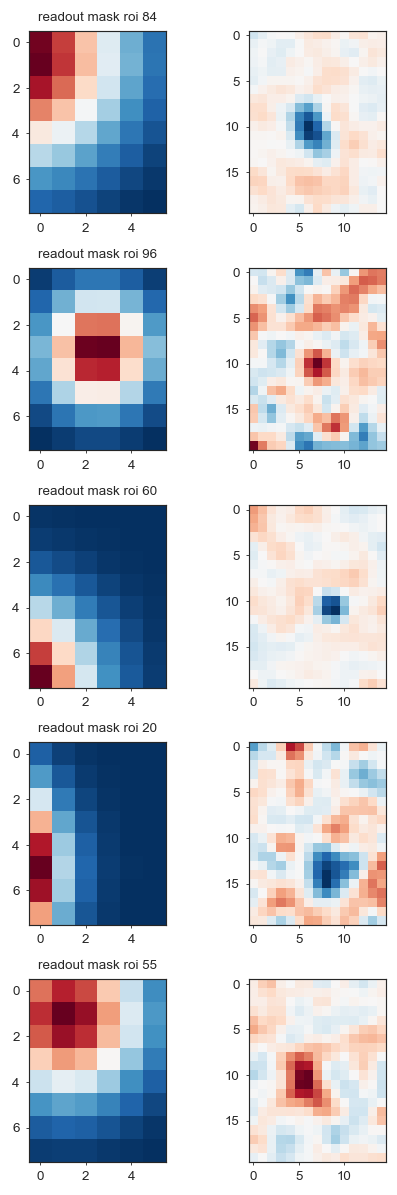

In [214]:
plot_many_rois(n_rois=5)

In [203]:
def plot_scatter_mask_rf(rf_data,model,session_id,ax= None):
    if ax is None:
        fig, ax = plt.subplots(1,2, figsize=(8,4))


    readout = model.readout[session_id]
    model_roi_ids = model.data_info["sessions_kwargs"][session_id]["roi_ids"]
    mask_mean = readout.mask_mean.detach().cpu().numpy()
    x_mask,y_mask =mask_mean[:,0], mask_mean[:,1] 

    if model.data_info["sessions_kwargs"][SESSION_ID]["eye"] == "left":
        print(f"Left retina, fllipping x_mask sign")
        x_mask = -x_mask

    rf_df = rf_data[session_id]
    rf_df = rf_df[rf_df["roi_id"].isin(model_roi_ids)].copy()
    x_rf,y_rf = [rf_df.apply(lambda row: row["srf_params"][key],axis = 1) for key in ["x_mean","y_mean"]]
    print(x_mask.shape, x_rf.shape)
    ax[0].scatter(x_mask, x_rf)
    ax[0].set_xlabel("x readout mask mean")
    ax[0].set_ylabel("x RF mean")

    ax[1].scatter(y_mask, y_rf)
    ax[1].set_xlabel("y readout mask mean")
    ax[1].set_ylabel("y RF mean")

    plt.tight_layout()

    return ax



Left retina, fllipping x_mask sign
(80,) (80,)


array([<Axes: xlabel='x readout mask mean', ylabel='x RF mean'>,
       <Axes: xlabel='y readout mask mean', ylabel='y RF mean'>],
      dtype=object)

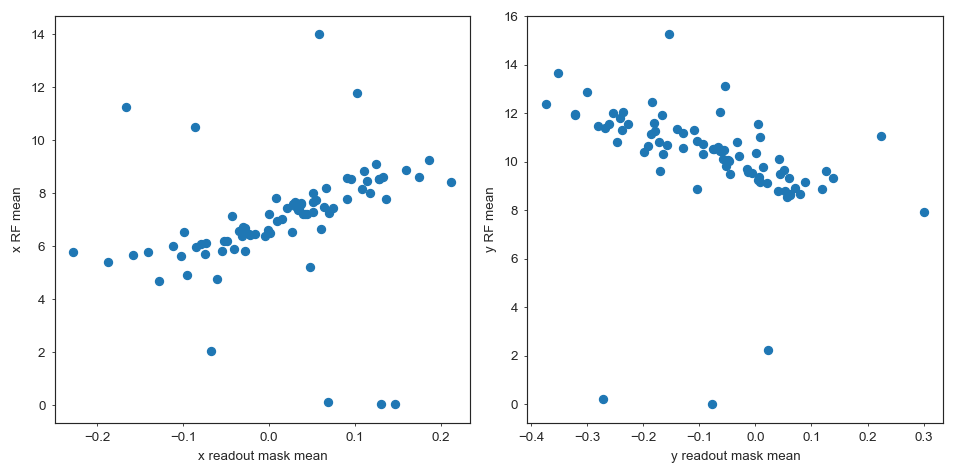

In [204]:
plot_scatter_mask_rf(rf_data, or_model, SESSION_ID)